## **Middleware**

- Tracking the agent behavior with logging , anlystics and debiging
- Transforming promt and section and output formating 

In [31]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# **Summarization Middleware**

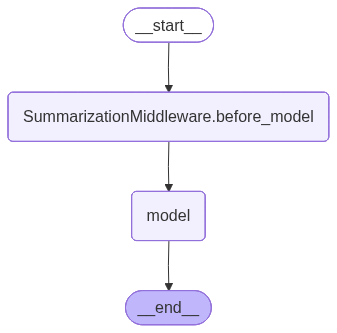

In [32]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage

## agent with Messages Summarrization 

agent = create_agent(
    model = "groq:qwen/qwen3-32b",
    checkpointer = InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [33]:
## thread id

config={"configurable":{"thread_id":"test1"}}

In [34]:
questions = [
    "what is 2+2?",
    "what is 3+3?",
    "what is 10*5?",
    "what is 100/5?",
    "what is 1000-500?",
    "what is 1000+500?",
]
for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"messages: {response}")
    print(f"messages: {len(response['messages'])}")

KeyboardInterrupt: 

## **onather Way to do same things**

**With help of Token Size**

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool


@tool
def search_hotels(city: str) -> str:
    """Search hotels and return available hotel options."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5-star, $350/night, spa, pool, gym
    2. City Inn - 4-star, $180/night, business centre
    3. Budget Stay - 3-star, $75/night, free Wi-Fi
    """


agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("tokens", 550),
            keep=("tokens", 200),
        )
    ],
)
config = {'configurable':{"thread_id":"test-1"}}

def count_tokens(messages):
    total_char = sum(len(str(m.content)) for m in messages)
    return total_char // 4

In [ ]:
cities = ["Paris","Landon","New Yark","Dubai","Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"find hotels in {city}")]},
        config=config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{response['messages']}")

Paris: ~128 tokens, 4 messages
HumanMessage : Find hotels in Paris
AIMessage : 
ToolMessage : Hotels in Paris:
    1. Grand Hotel - 5-star, $350/night, spa, pool, gym
    2. City Inn - 4-star, $180/night, business centre
    3. Budget Stay - 3-star, $75/night, free Wi-Fi
    
AIMessage : Here are some hotel options in Paris:

1. **Grand Hotel** - 5-star, $350/night  
   *Amenities*: Spa, pool, gym  
   
2. **City Inn** - 4-star, $180/night  
   *Amenities*: Business centre  
   
3. **Budget Stay** - 3-star, $75/night  
   *Amenities*: Free Wi-Fi  

Let me know if you'd like help booking one! 😊
--------------------------------------------------
London: ~771 tokens, 6 messages
HumanMessage : Here is a summary of the conversation to date:

<think>
Alright, let's tackle this. The user's main goal is to find hotels in Paris. The assistant used the search_hotels tool with Paris as the city. The response listed three hotels with different features and prices.

First, the SESSION INTENT should

KeyboardInterrupt: 